# Tech Challenge - Pipeline Completo de Atrasos de Voos

Este notebook consolida o pipeline do projeto, indo do entendimento inicial dos dados até a modelagem supervisionada, a abordagem não supervisionada e as conclusões finais.

Nas aulas, o fluxo foi apresentado como uma sequência lógica: entender a base, tratar os dados, explorar padrões, modelar e interpretar os resultados. Vou seguir exatamente essa linha aqui, eliminando repetições e mantendo apenas o que é mais relevante para a entrega e para a apresentação.

## 1. Importação e Carga dos Dados

Para essa entrega vou focar na base `flights.csv`, que concentra todas as informações operacionais dos voos. Começo fazendo uma visão descritiva sobre o tipo da estrutura e da qualidade desses dados (como o volume de nulos) antes de partir para a montagem dos modelos.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, silhouette_score, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid', palette='Set2')

# Importação e carga de dados e leitura do head do dataset

df_flights = pd.read_csv('./data/flights.csv', low_memory=False)

print(f'Linhas: {df_flights.shape[0]:,}')
print(f'Colunas: {df_flights.shape[1]}')
display(df_flights.head())

Linhas: 5,819,079
Colunas: 31


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Entendimento Inicial da Base

Primeira etapa, entender o que existe na tabela. Aqui, o objetivo é ter uma visão geral sobre:
- tamanho da base;
- tipos de variáveis;
- estatísticas descritivas básicas;
- volume de valores ausentes.

In [45]:
# Colunas e tipos de dados
print('======= Colunas e Tipos de Dados =======\n')
df_flights.info()

# Estatísticas descritivas. Quantidade de valores únicos, média, desvio padrão, mínimo, máximo e quartis.
print('======= Estatísticas Descritivas =======\n')
display(df_flights.describe(include='all').T.head(30))

# Top 10 colunas com mais valores faltantes
print('======= Valores Faltantes/Nulos =======\n')
missing_df = (
    df_flights.isna()
    .sum()
    .sort_values(ascending=False)
    .rename('missing_count')
    .reset_index()
    .rename(columns={'index': 'column'})
)
missing_df['missing_pct'] = (missing_df['missing_count'] / len(df_flights) * 100).round(2)

display(missing_df.head(17))

======= Colunas e Tipos de Dados =======

<class 'pandas.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              str    
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          str    
 7   ORIGIN_AIRPORT       str    
 8   DESTINATION_AIRPORT  str    
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  D

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
YEAR,5819079.0,NaN,NaN,NaN,2015.0,0.0,2015.0,2015.0,2015.0,2015.0,2015.0
MONTH,5819079.0,NaN,NaN,NaN,6.524085,3.405137,1.0,4.0,7.0,9.0,12.0
DAY,5819079.0,NaN,NaN,NaN,15.704594,8.783425,1.0,8.0,16.0,23.0,31.0
DAY_OF_WEEK,5819079.0,NaN,NaN,NaN,3.926941,1.988845,1.0,2.0,4.0,6.0,7.0
AIRLINE,5819079,14,WN,1261855,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLIGHT_NUMBER,5819079.0,NaN,NaN,NaN,2173.092742,1757.063999,1.0,730.0,1690.0,3230.0,9855.0
TAIL_NUMBER,5804358,4897,N480HA,3768,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ORIGIN_AIRPORT,5819079,628,ATL,346836,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DESTINATION_AIRPORT,5819079,629,ATL,346904,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCHEDULED_DEPARTURE,5819079.0,NaN,NaN,NaN,1329.60247,483.751821,1.0,917.0,1325.0,1730.0,2359.0


======= Valores Faltantes/Nulos =======



,column,missing_count,missing_pct
0,CANCELLATION_REASON,5729195,98.46
1,LATE_AIRCRAFT_DELAY,4755640,81.72
2,WEATHER_DELAY,4755640,81.72
3,AIRLINE_DELAY,4755640,81.72
4,AIR_SYSTEM_DELAY,4755640,81.72
5,SECURITY_DELAY,4755640,81.72
6,ELAPSED_TIME,105071,1.81
7,AIR_TIME,105071,1.81
8,ARRIVAL_DELAY,105071,1.81
9,WHEELS_ON,92513,1.59


### Leitura Inicial

O que mais chama atenção na qualidade dos dados é que a maior parte dos nulos aparece em colunas ligadas a motivos de atraso ou cancelamento. Isso faz sentido operacionalmente: essas informações só existem depois que o evento aconteceu.

Como o foco do projeto é previsão e exploração de padrões, essas colunas não vão entrar como explicação do futuro na modelagem supervisionada.

## 3. Base Analítica e Definição do Alvo

Para a parte supervisionada, vou tratar o problema como classificação: prever se o voo vai chegar atrasado ou não.

O alvo será:
- `1` se `ARRIVAL_DELAY > 0`
- `0` caso contrário

Também vou restringir a base a voos que realmente chegaram ao destino da forma esperada, ou seja, sem cancelamento e sem desvio. Isso deixa a comparação mais coerente para a previsão de atraso na chegada.

In [46]:
# Filtra voos que foram realmente realizados (não cancelados nem desviados)
df_analysis = df_flights.loc[
    (df_flights['CANCELLED'] == 0) &
    (df_flights['DIVERTED'] == 0)
].copy()

# SCHEDULED_DEPARTURE e SCHEDULED_ARRIVAL estão no formato HHMM.
df_analysis['DEP_MIN_OF_DAY'] = ((df_analysis['SCHEDULED_DEPARTURE'] // 100) * 60 + (df_analysis['SCHEDULED_DEPARTURE'] % 100)).astype('Int64')
df_analysis['ARR_MIN_OF_DAY'] = ((df_analysis['SCHEDULED_ARRIVAL'] // 100) * 60 + (df_analysis['SCHEDULED_ARRIVAL'] % 100)).astype('Int64')

# Target 1: Atrasos maiores que 0 minutos
df_analysis['TARGET_DELAY'] = (df_analysis['ARRIVAL_DELAY'] > 0).astype(int)

# Target 2 (Novo): Atrasos maiores que 15 minutos (tolerância operacional)
df_analysis['TARGET_DELAY_15'] = (df_analysis['ARRIVAL_DELAY'] > 15).astype(int)

print(f'Base analitica: {len(df_analysis):,} voos')
print(f'Taxa de voos com atraso > 0 min: {df_analysis["TARGET_DELAY"].mean():.2%}')
print(f'Taxa de voos com atraso > 15 min: {df_analysis["TARGET_DELAY_15"].mean():.2%}')

Base analitica: 5,714,008 voos
Taxa de voos com atraso > 0 min: 36.52%
Taxa de voos com atraso > 15 min: 17.91%


## 4. EDA Essencial

Este bloco foca em extrair evidências operacionais e de qualidade de dados para orientar a modelagem. A ideia é responder: onde e quando ficam os atrasos e que variáveis iniciais parecem mais úteis.

Vamos investigar:
- qualidade da base e concentração de nulos;
- estatísticas de atraso (tendência central e dispersão);
- distribuição e outliers de `ARRIVAL_DELAY`;
- taxa de atraso por companhia aérea e por aeroporto de origem;
- sazonalidade por mês, dia da semana, período do dia e horário previsto de saída.

Resumo estatistico dos atrasos de partida e chegada (unidade: minutos):


,count,mean,std,min,25%,50%,75%,max
DEPARTURE_DELAY,5714008.0,9.29,36.89,-82.0,-5.0,-2.0,7.0,1988.0
ARRIVAL_DELAY,5714008.0,4.41,39.27,-87.0,-13.0,-5.0,8.0,1971.0


Proporção de voos com atraso de 15 minutos ou menos: 82.09%


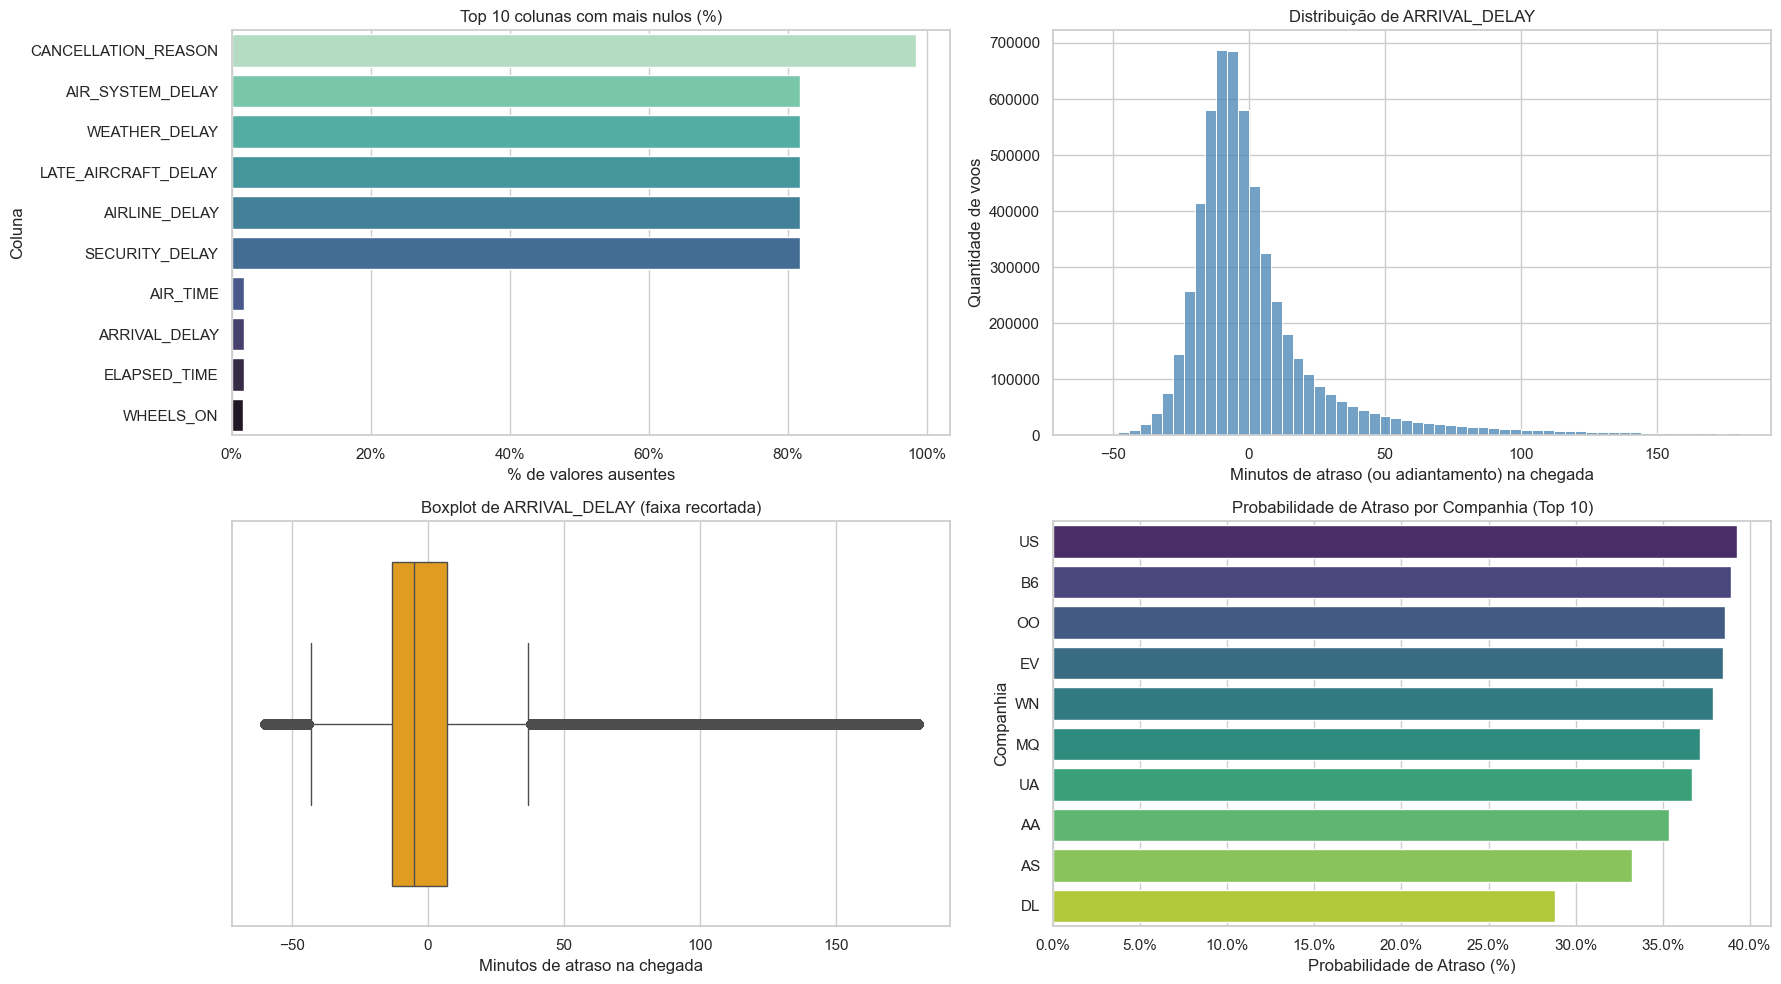

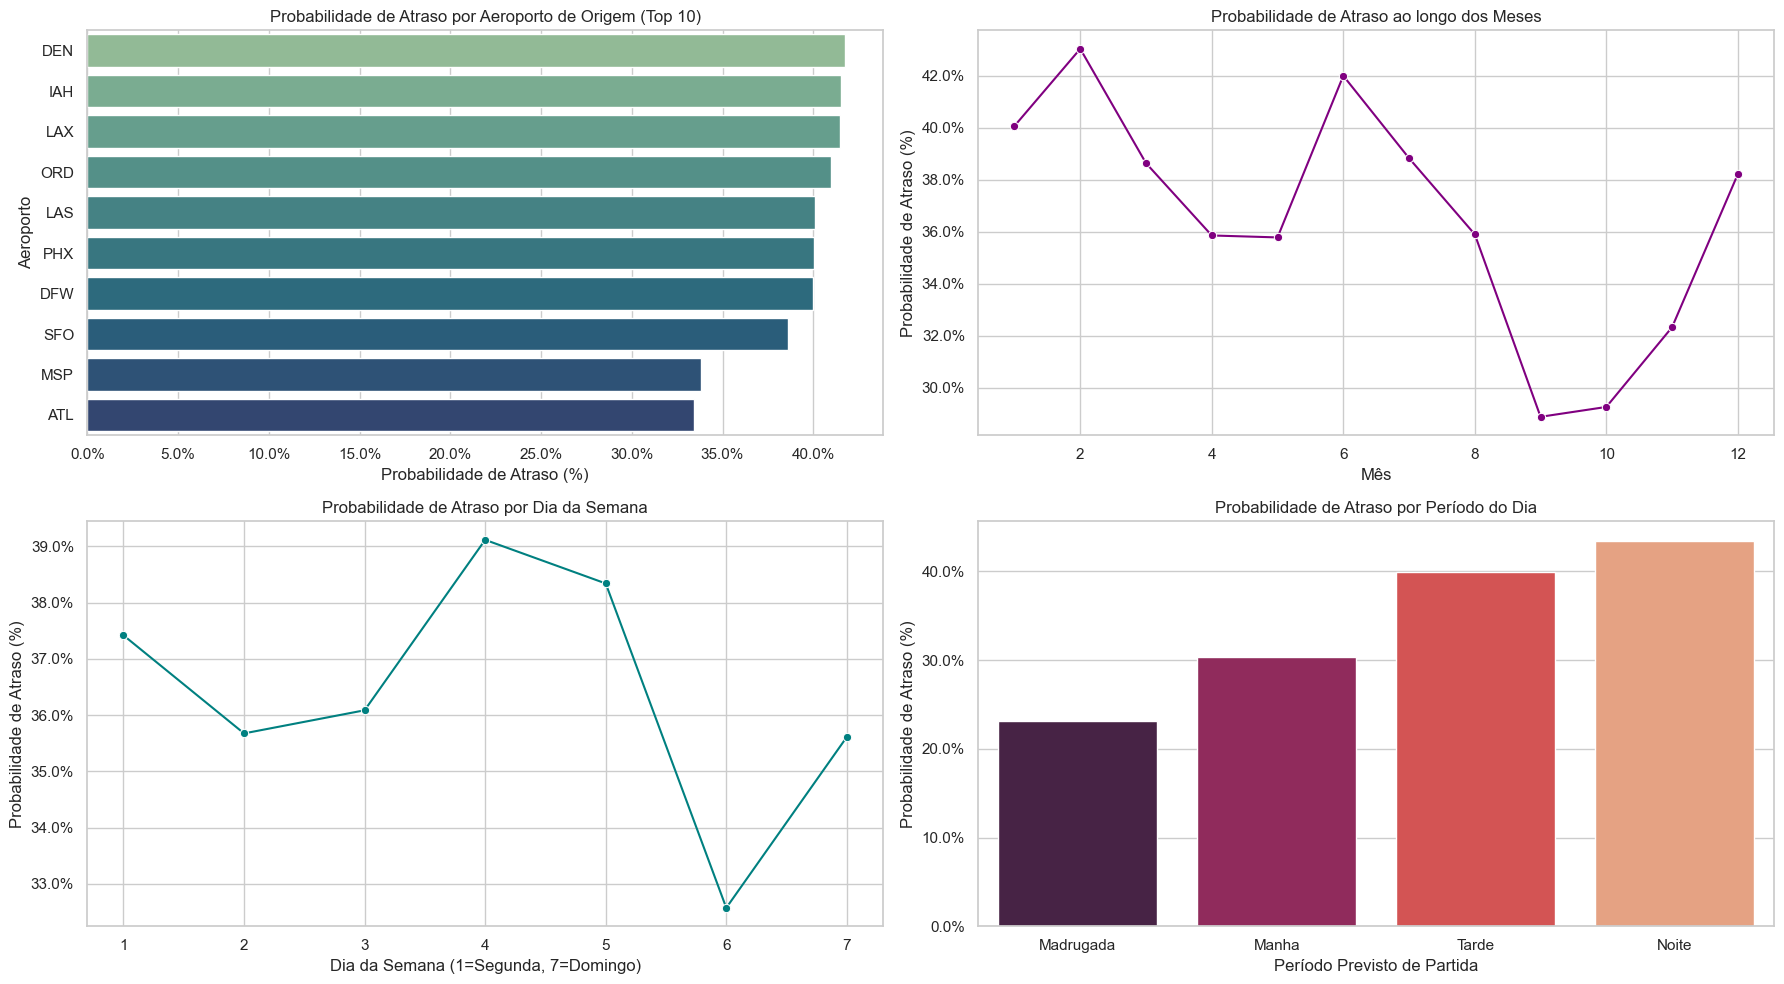

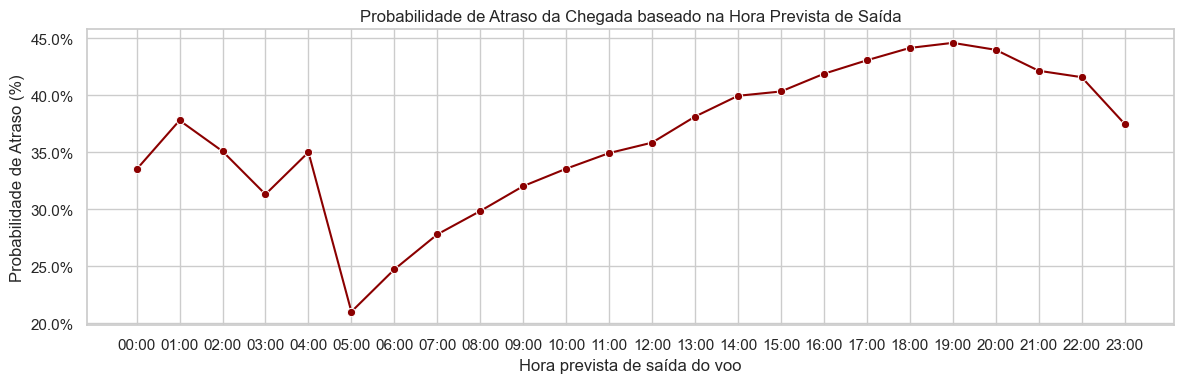

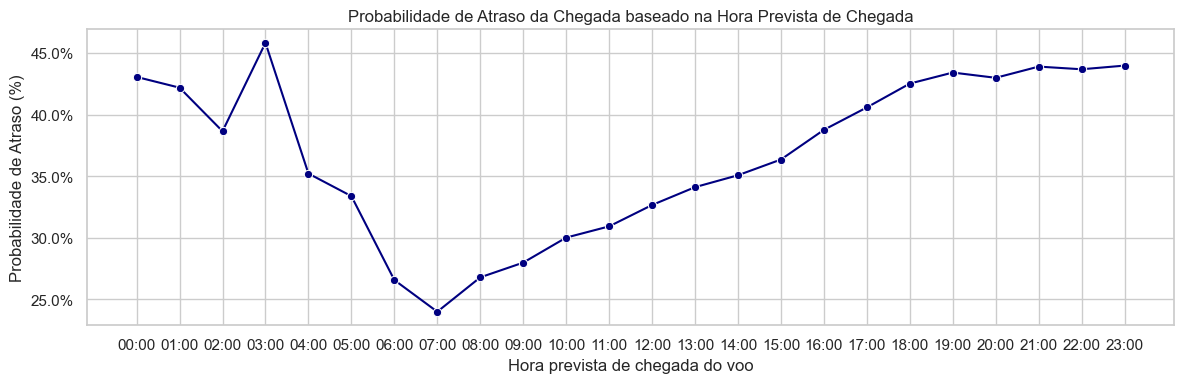

Limites de outlier por IQR para ARRIVAL_DELAY: [-44.50, 39.50]


In [47]:
# Seleciona as 10 colunas com mais valores faltantes para visualização
missing_top = missing_df.nlargest(10, 'missing_pct').sort_values('missing_pct', ascending=True)

# Resumo estatístico para variáveis de atraso
delay_stats = df_analysis[['DEPARTURE_DELAY', 'ARRIVAL_DELAY']].describe().T.round(2)

# Quantos voos chegam com atraso de 15 minutos ou menos (considerando que isso pode ser um "atraso operacionalmente aceitável")?
delay_stats_15 = (df_analysis['ARRIVAL_DELAY'] <= 15).mean()

# Remove valores muito extremos apenas para visualização mais limpa no histograma e boxplot
delay_clip = df_analysis.loc[df_analysis['ARRIVAL_DELAY'].between(-60, 180), 'ARRIVAL_DELAY']

# Cálculo do IQR (Intervalo Interquartil) e limites para identificação de outliers
q1 = df_analysis['ARRIVAL_DELAY'].quantile(0.25)
q3 = df_analysis['ARRIVAL_DELAY'].quantile(0.75)
iqr = q3 - q1
lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

# Cria a hora prevista de saída e de chegada a partir dos minutos do dia (usamos % 24 para que 24:00 vire 00:00 da madrugada)
df_analysis['DEP_HOUR'] = (df_analysis['DEP_MIN_OF_DAY'] // 60) % 24
df_analysis['ARR_HOUR'] = (df_analysis['ARR_MIN_OF_DAY'] // 60) % 24

# Classifica a hora de partida em quatro grandes períodos do dia
df_analysis['DEP_PERIOD'] = pd.cut(df_analysis['DEP_HOUR'],bins=[-1, 5, 11, 17, 23], labels=['Madrugada', 'Manha', 'Tarde', 'Noite'])

# Agrupa e calcula a taxa de atraso por companhia (apenas as 10 maiores)
airline_summary = (
    df_analysis.groupby('AIRLINE')
    .agg(total_voos=('AIRLINE', 'size'), taxa_atraso=('TARGET_DELAY', 'mean'))
    .sort_values('total_voos', ascending=False)
    .head(10)
    .sort_values('taxa_atraso', ascending=False)
)

# Agrupa e calcula a taxa de atraso por aeroporto de origem (apenas os 10 maiores)
airport_summary = (
    df_analysis.groupby('ORIGIN_AIRPORT')
    .agg(total_voos=('ORIGIN_AIRPORT', 'size'), taxa_atraso=('TARGET_DELAY', 'mean'))
    .sort_values('total_voos', ascending=False)
    .head(10)
    .sort_values('taxa_atraso', ascending=False)
)

# Agrupamentos de sazonalidade temporal
month_summary = (df_analysis.groupby('MONTH').agg(taxa_atraso=('TARGET_DELAY', 'mean')).reset_index())

day_of_week_summary = (df_analysis.groupby('DAY_OF_WEEK').agg(taxa_atraso=('TARGET_DELAY', 'mean')).reset_index())

period_summary = (df_analysis.groupby('DEP_PERIOD', observed=False).agg(taxa_atraso=('TARGET_DELAY', 'mean')).reset_index())

dep_hour_summary = (df_analysis.groupby('DEP_HOUR').agg(taxa_atraso=('TARGET_DELAY', 'mean')).reset_index())

arr_hour_summary = (df_analysis.groupby('ARR_HOUR').agg(taxa_atraso=('TARGET_DELAY', 'mean')).reset_index())

print('Resumo estatistico dos atrasos de partida e chegada (unidade: minutos):')
display(delay_stats)

print(f'Proporção de voos com atraso de 15 minutos ou menos: {delay_stats_15:.2%}')

import matplotlib.ticker as mtick

# Configuração da primeira grade de gráficos (Nulos, Dist. de Atraso, Boxplot, Probabilidade de Atraso por Cia)
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

sns.barplot(data=missing_top, x='missing_pct', y='column', ax=axes[0, 0], palette='mako')
axes[0, 0].invert_yaxis()
axes[0, 0].set_title('Top 10 colunas com mais nulos (%)')
axes[0, 0].set_xlabel('% de valores ausentes')
axes[0, 0].set_ylabel('Coluna')
axes[0, 0].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))

sns.histplot(delay_clip, bins=60, ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('Distribuição de ARRIVAL_DELAY')
axes[0, 1].set_xlabel('Minutos de atraso (ou adiantamento) na chegada')
axes[0, 1].set_ylabel('Quantidade de voos')

sns.boxplot(x=delay_clip, ax=axes[1, 0], color='orange')
axes[1, 0].set_title('Boxplot de ARRIVAL_DELAY (faixa recortada)')
axes[1, 0].set_xlabel('Minutos de atraso na chegada')

sns.barplot(data=airline_summary.reset_index(), x='taxa_atraso', y='AIRLINE', ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Probabilidade de Atraso por Companhia (Top 10)')
axes[1, 1].set_xlabel('Probabilidade de Atraso (%)')
axes[1, 1].set_ylabel('Companhia')
axes[1, 1].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

plt.tight_layout()
plt.show()

# Configuração da segunda grade de gráficos (Aeroportos e Sazonalidade: Mês, Dia, Período)
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

sns.barplot(data=airport_summary.reset_index(), x='taxa_atraso', y='ORIGIN_AIRPORT', ax=axes[0, 0], palette='crest')
axes[0, 0].set_title('Probabilidade de Atraso por Aeroporto de Origem (Top 10)')
axes[0, 0].set_xlabel('Probabilidade de Atraso (%)')
axes[0, 0].set_ylabel('Aeroporto')
axes[0, 0].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

sns.lineplot(data=month_summary, x='MONTH', y='taxa_atraso', marker='o', ax=axes[0, 1], color='purple')
axes[0, 1].set_title('Probabilidade de Atraso ao longo dos Meses')
axes[0, 1].set_xlabel('Mês')
axes[0, 1].set_ylabel('Probabilidade de Atraso (%)')
axes[0, 1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

sns.lineplot(data=day_of_week_summary, x='DAY_OF_WEEK', y='taxa_atraso', marker='o', ax=axes[1, 0], color='teal')
axes[1, 0].set_title('Probabilidade de Atraso por Dia da Semana')
axes[1, 0].set_xlabel('Dia da Semana (1=Segunda, 7=Domingo)')
axes[1, 0].set_ylabel('Probabilidade de Atraso (%)')
axes[1, 0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

sns.barplot(data=period_summary, x='DEP_PERIOD', y='taxa_atraso', ax=axes[1, 1], palette='rocket')
axes[1, 1].set_title('Probabilidade de Atraso por Período do Dia')
axes[1, 1].set_xlabel('Período Previsto de Partida')
axes[1, 1].set_ylabel('Probabilidade de Atraso (%)')
axes[1, 1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

plt.tight_layout()
plt.show()

# Gráfico de detalhamento da sazonalidade por hora prevista de saída
plt.figure(figsize=(12, 4))
ax = sns.lineplot(data=dep_hour_summary, x='DEP_HOUR', y='taxa_atraso', marker='o', color='darkred')

ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)])
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

plt.title('Probabilidade de Atraso da Chegada baseado na Hora Prevista de Saída')
plt.xlabel('Hora prevista de saída do voo')
plt.ylabel('Probabilidade de Atraso (%)')
plt.tight_layout()
plt.show()

# Gráfico de detalhamento da sazonalidade por hora prevista de chegada
plt.figure(figsize=(12, 4))
ax = sns.lineplot(data=arr_hour_summary, x='ARR_HOUR', y='taxa_atraso', marker='o', color='navy')

ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)])
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

plt.title('Probabilidade de Atraso da Chegada baseado na Hora Prevista de Chegada')
plt.xlabel('Hora prevista de chegada do voo')
plt.ylabel('Probabilidade de Atraso (%)')
plt.tight_layout()
plt.show()

# Exibe os limites matemáticos calculados para outliers de atraso
print(f'Limites de outlier por IQR para ARRIVAL_DELAY: [{lim_inf:.2f}, {lim_sup:.2f}]')

### Leitura do EDA

A leitura sintetizada do EDA é a seguinte:
- `ARRIVAL_DELAY` tem distribuição assimétrica à direita, com muitos voos próximos do horário previsto e poucos atrasos extremos puxando a média para cima.
- O comportamento típico dos voos é chegar no horário ou levemente adiantado, mas há outliers relevantes de atraso.
- As colunas com mais nulos concentram-se principalmente nas variáveis que explicam motivo de atraso e cancelamento, o que é coerente com preenchimento condicionado ao evento.
- Há diferença relevante na probabilidade de atraso entre companhias aéreas e entre aeroportos de origem, indicando sinal preditivo nessas variáveis.
- Existe sazonalidade temporal: a probabilidade de atraso varia por mês, dia da semana e período do dia.
- A madrugada concentra menor probabilidade de atraso, enquanto tarde e noite apresentam risco maior.
- Os gráficos por hora prevista de saída e de chegada mostram aumento da probabilidade de atraso ao longo do dia, sugerindo acúmulo operacional na malha aérea.

## 5. Preparação para a Modelagem Supervisionada

Para a classificação, vou manter apenas variáveis disponíveis antes do voo acontecer. Isso evita usar informações que, na prática, só seriam conhecidas depois do evento.

As variáveis escolhidas serão:
- `MONTH`, `DAY`, `DAY_OF_WEEK`
- `AIRLINE`, `ORIGIN_AIRPORT`, `DESTINATION_AIRPORT`
- `DISTANCE`, `SCHEDULED_TIME`, `DEP_MIN_OF_DAY`, `ARR_MIN_OF_DAY`

Nas aulas, a separação entre treino e teste aparece como etapa central. Por isso, vou fazer essa divisão antes de qualquer transformação.

In [48]:
features_sup = [
    'MONTH',
    'DAY',
    'DAY_OF_WEEK',
    'AIRLINE',
    'ORIGIN_AIRPORT',
    'DESTINATION_AIRPORT',
    'DISTANCE',
    'SCHEDULED_TIME',
    'DEP_MIN_OF_DAY',
    'ARR_MIN_OF_DAY'
]

X = df_analysis[features_sup].copy()
y = df_analysis['TARGET_DELAY'].copy()
y_15 = df_analysis['TARGET_DELAY_15'].copy()

# Divisão incluindo os dois alvos ao mesmo tempo para garantir que as linhas de teste/treino sejam idênticas
X_train, X_test, y_train, y_test, y_train_15, y_test_15 = train_test_split(
    X,
    y,
    y_15,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f'Treino: {X_train.shape[0]:,} linhas')
print(f'Teste: {X_test.shape[0]:,} linhas')
print(f'Taxa de atraso (>0) no treino: {y_train.mean():.2%}')
print(f'Taxa de atraso (>15) no treino: {y_train_15.mean():.2%}')

Treino: 3,999,805 linhas
Teste: 1,714,203 linhas
Taxa de atraso (>0) no treino: 36.52%
Taxa de atraso (>15) no treino: 17.91%


## 6. Baseline e Modelos Supervisionados

Vou comparar três referências:
- **Baseline/Modelo mais simples**: prever sempre a classe majoritária;
- **Regressão Logística**: baseline supervisionado linear;
- **XGBoost**: modelo mais flexível para capturar relações não lineares.

Para manter a leitura limpa, vou usar uma função auxiliar de avaliação e consolidar tudo em uma tabela ao final.

,Modelo,Accuracy,Precision_atraso,Recall_atraso,F1_atraso
0,XGBoost (>0),0.6579,0.5259,0.6439,0.5789
1,Regressao Logistica (>0),0.5877,0.4509,0.5920,0.5119
2,Baseline classe majoritaria (>0),0.6348,0.0000,0.0000,0.0000


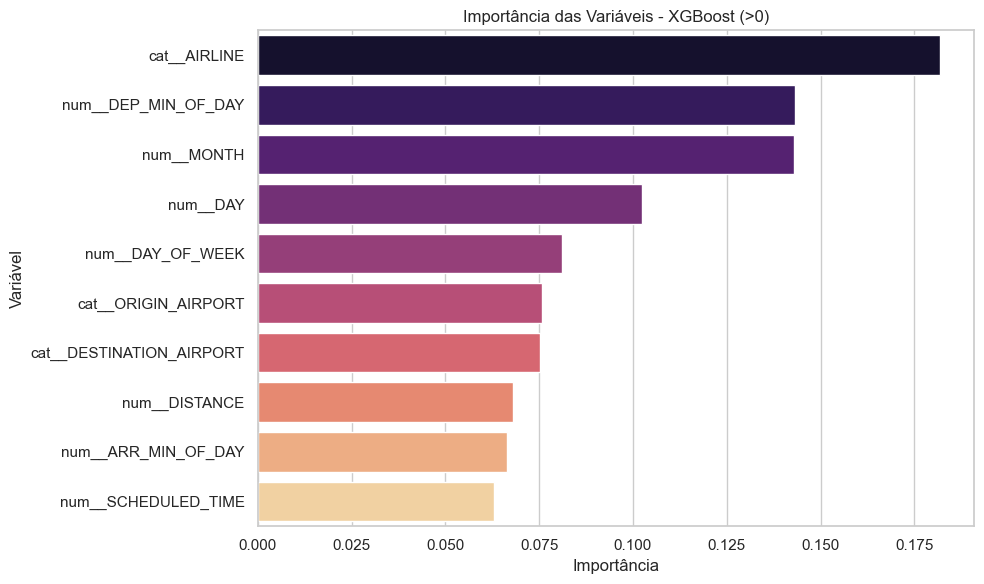

,feature,importance
0,cat__AIRLINE,0.181821
1,num__DEP_MIN_OF_DAY,0.143200
2,num__MONTH,0.142872
3,num__DAY,0.102389
4,num__DAY_OF_WEEK,0.081149
5,cat__ORIGIN_AIRPORT,0.075796
6,cat__DESTINATION_AIRPORT,0.075223
7,num__DISTANCE,0.067977
8,num__ARR_MIN_OF_DAY,0.066529
9,num__SCHEDULED_TIME,0.063043


<Figure size 800x600 with 0 Axes>

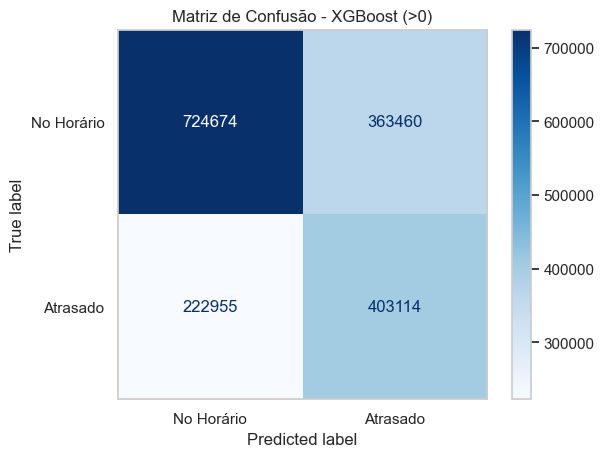

,Modelo,Accuracy,Precision_atraso,Recall_atraso,F1_atraso
0,XGBoost (>0),0.6579,0.5259,0.6439,0.5789
1,XGBoost (>15),0.6911,0.3242,0.6665,0.4362


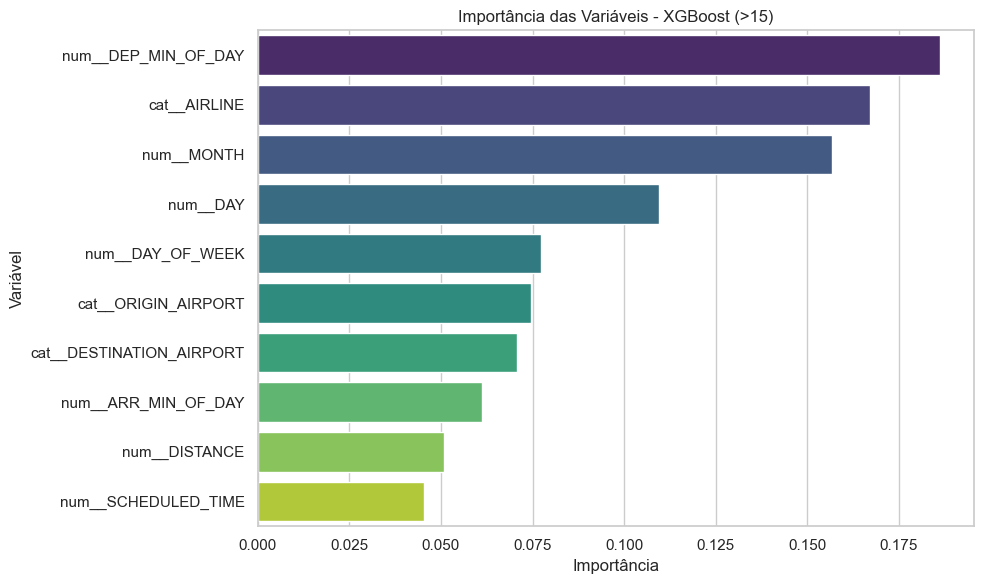

,feature,importance
0,num__DEP_MIN_OF_DAY,0.186222
1,cat__AIRLINE,0.167168
2,num__MONTH,0.156881
3,num__DAY,0.109537
4,num__DAY_OF_WEEK,0.077391
5,cat__ORIGIN_AIRPORT,0.074517
6,cat__DESTINATION_AIRPORT,0.070866
7,num__ARR_MIN_OF_DAY,0.061105
8,num__DISTANCE,0.050944
9,num__SCHEDULED_TIME,0.045370


<Figure size 800x600 with 0 Axes>

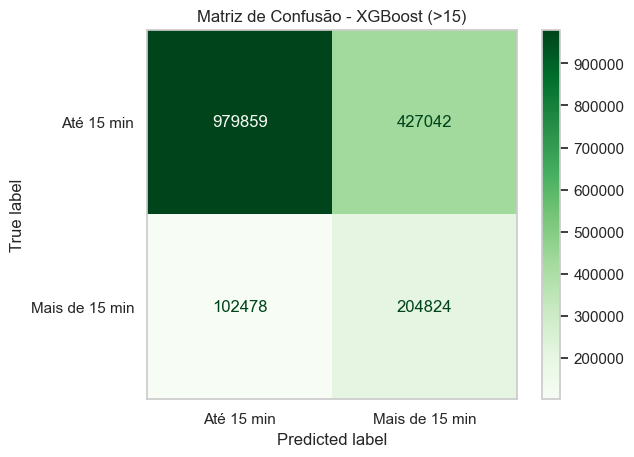

In [49]:
categorical_features = ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']
numeric_features = ['MONTH', 'DAY', 'DAY_OF_WEEK', 'DISTANCE', 'SCHEDULED_TIME', 'DEP_MIN_OF_DAY', 'ARR_MIN_OF_DAY']

# Substitui valores nulos por 'missing' para as variáveis categóricas e aplica OneHotEncoder para Regressão Logística
categorical_pipeline_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', dtype=np.float32))
])

categorical_pipeline_xgb = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor_lr = ColumnTransformer(
    transformers=[
        ('cat', categorical_pipeline_lr, categorical_features),
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features)
    ]
)

preprocessor_xgb = ColumnTransformer(
    transformers=[
        ('cat', categorical_pipeline_xgb, categorical_features),
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]), numeric_features)
    ]
)

def evaluate_binary_model(model_name, y_true, y_pred):
    return {
        'Modelo': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision_atraso': precision_score(y_true, y_pred, zero_division=0),
        'Recall_atraso': recall_score(y_true, y_pred, zero_division=0),
        'F1_atraso': f1_score(y_true, y_pred, zero_division=0)
    }

# ==========================================
# Base do notebook: usar df_analysis já pronto
# ==========================================

X = df_analysis[categorical_features + numeric_features].copy()
y = df_analysis['TARGET_DELAY'].copy()         # atraso > 0
y_15 = df_analysis['TARGET_DELAY_15'].copy()   # atraso > 15

# Divisão única para manter as mesmas linhas nos dois cenários
X_train, X_test, y_train, y_test, y_train_15, y_test_15 = train_test_split(
    X,
    y,
    y_15,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# CENÁRIO 1: ATRASO > 0 MIN

# Baseline de classe majoritária
y_pred_baseline = np.zeros_like(y_test)
metrics_baseline = evaluate_binary_model('Baseline classe majoritaria (>0)', y_test, y_pred_baseline)

# Regressão Logística em amostra estratificada do treino
lr_train_fraction = 0.25
X_train_lr, _, y_train_lr, _ = train_test_split(
    X_train,
    y_train,
    train_size=lr_train_fraction,
    random_state=42,
    stratify=y_train
)

pipeline_lr = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('model', LogisticRegression(
        class_weight='balanced',
        solver='saga',
        max_iter=100,
        tol=1e-2,
        n_jobs=-1,
        random_state=42
    ))
])

pipeline_lr.fit(X_train_lr, y_train_lr)
y_pred_lr = pipeline_lr.predict(X_test)
metrics_lr = evaluate_binary_model('Regressao Logistica (>0)', y_test, y_pred_lr)

# XGBoost com GPU
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor_xgb),
    ('model', XGBClassifier(
        n_estimators=150,
        max_depth=8,
        scale_pos_weight=scale_pos_weight,
        tree_method='hist',
        device='cuda',
        eval_metric='logloss',
        random_state=42
    ))
])

pipeline_xgb.fit(X_train, y_train)

y_pred_xgb = pipeline_xgb.predict(X_test)
metrics_xgb = evaluate_binary_model('XGBoost (>0)', y_test, y_pred_xgb)

# Consolidação dos resultados (>0)
comparison_df = pd.DataFrame([metrics_baseline, metrics_lr, metrics_xgb]).copy()
metric_cols = ['Accuracy', 'Precision_atraso', 'Recall_atraso', 'F1_atraso']
comparison_df[metric_cols] = comparison_df[metric_cols].round(4)
comparison_df = comparison_df.sort_values('F1_atraso', ascending=False).reset_index(drop=True)

display(comparison_df)

# Interpretabilidade: Importância das Variáveis (>0)
xgb_model = pipeline_xgb.named_steps['model']
xgb_preprocessor = pipeline_xgb.named_steps['preprocessor']

feature_names = xgb_preprocessor.get_feature_names_out()
importances = xgb_model.feature_importances_

feature_importance_df = (
    pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df.head(15), x='importance', y='feature', palette='magma')
plt.title('Importância das Variáveis - XGBoost (>0)')
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.tight_layout()
plt.show()

display(feature_importance_df.head(15))

# Matriz de confusão (>0)
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    display_labels=['No Horário', 'Atrasado'],
    cmap='Blues',
    values_format='d'
)
plt.title('Matriz de Confusão - XGBoost (>0)')
plt.grid(False)
plt.show()



# CENÁRIO 2: ATRASO > 15 MIN

# Baseline
y_pred_baseline_15 = np.zeros_like(y_test_15)
metrics_baseline_15 = evaluate_binary_model('Baseline classe majoritaria (>15)', y_test_15, y_pred_baseline_15)

# XGBoost com GPU
scale_pos_weight_15 = (y_train_15 == 0).sum() / (y_train_15 == 1).sum()

pipeline_xgb_15 = Pipeline([
    ('preprocessor', preprocessor_xgb),
    ('model', XGBClassifier(
        n_estimators=150,
        max_depth=8,
        scale_pos_weight=scale_pos_weight_15,
        tree_method='hist',
        device='cuda',
        eval_metric='logloss',
        random_state=42
    ))
])

pipeline_xgb_15.fit(X_train, y_train_15)

y_pred_xgb_15 = pipeline_xgb_15.predict(X_test)
metrics_xgb_15 = evaluate_binary_model('XGBoost (>15)', y_test_15, y_pred_xgb_15)

# Comparação entre os dois targets no XGBoost
comparison_xgb_targets_df = pd.DataFrame([
    metrics_xgb,
    metrics_xgb_15
]).copy()

comparison_xgb_targets_df[metric_cols] = comparison_xgb_targets_df[metric_cols].round(4)
comparison_xgb_targets_df = comparison_xgb_targets_df.sort_values('F1_atraso', ascending=False).reset_index(drop=True)

display(comparison_xgb_targets_df)

# Importância das variáveis (>15)
xgb_model_15 = pipeline_xgb_15.named_steps['model']
xgb_preprocessor_15 = pipeline_xgb_15.named_steps['preprocessor']

feature_names_15 = xgb_preprocessor_15.get_feature_names_out()
importances_15 = xgb_model_15.feature_importances_

feature_importance_df_15 = (
    pd.DataFrame({
        'feature': feature_names_15,
        'importance': importances_15
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df_15.head(15), x='importance', y='feature', palette='viridis')
plt.title('Importância das Variáveis - XGBoost (>15)')
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.tight_layout()
plt.show()

display(feature_importance_df_15.head(15))

# Matriz de confusão (>15)
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_15,
    y_pred_xgb_15,
    display_labels=['Até 15 min', 'Mais de 15 min'],
    cmap='Greens',
    values_format='d'
)
plt.title('Matriz de Confusão - XGBoost (>15)')
plt.grid(False)
plt.show()

In [50]:
# Demonstração de inferência com dados 100% fictícios no modelo XGBoost treinado (>0 min)
cenarios_ficticios = pd.DataFrame([
    {
        'MONTH': 1,
        'DAY': 3,
        'DAY_OF_WEEK': 6,
        'AIRLINE': 'AA',
        'ORIGIN_AIRPORT': 'JFK',
        'DESTINATION_AIRPORT': 'LAX',
        'DISTANCE': 2475,
        'SCHEDULED_TIME': 370,
        'DEP_MIN_OF_DAY': 6 * 60 + 30,
        'ARR_MIN_OF_DAY': 9 * 60 + 40
    },
    {
        'MONTH': 7,
        'DAY': 15,
        'DAY_OF_WEEK': 3,
        'AIRLINE': 'WN',
        'ORIGIN_AIRPORT': 'DEN',
        'DESTINATION_AIRPORT': 'PHX',
        'DISTANCE': 602,
        'SCHEDULED_TIME': 115,
        'DEP_MIN_OF_DAY': 17 * 60 + 20,
        'ARR_MIN_OF_DAY': 19 * 60 + 15
    },
    {
        'MONTH': 11,
        'DAY': 27,
        'DAY_OF_WEEK': 5,
        'AIRLINE': 'DL',
        'ORIGIN_AIRPORT': 'ATL',
        'DESTINATION_AIRPORT': 'MIA',
        'DISTANCE': 595,
        'SCHEDULED_TIME': 125,
        'DEP_MIN_OF_DAY': 20 * 60 + 10,
        'ARR_MIN_OF_DAY': 22 * 60 + 15
    },
    {
        'MONTH': 3,
        'DAY': 9,
        'DAY_OF_WEEK': 1,
        'AIRLINE': 'UA',
        'ORIGIN_AIRPORT': 'SFO',
        'DESTINATION_AIRPORT': 'SEA',
        'DISTANCE': 679,
        'SCHEDULED_TIME': 130,
        'DEP_MIN_OF_DAY': 7 * 60 + 45,
        'ARR_MIN_OF_DAY': 9 * 60 + 55
    },
    {
        'MONTH': 12,
        'DAY': 31,
        'DAY_OF_WEEK': 4,
        'AIRLINE': 'B6',
        'ORIGIN_AIRPORT': 'BOS',
        'DESTINATION_AIRPORT': 'MCO',
        'DISTANCE': 1121,
        'SCHEDULED_TIME': 205,
        'DEP_MIN_OF_DAY': 21 * 60 + 0,
        'ARR_MIN_OF_DAY': 0 * 60 + 25
    }
])[features_sup].copy()

proba_atraso_ficticio = pipeline_xgb.predict_proba(cenarios_ficticios)[:, 1]
pred_atraso_ficticio = (proba_atraso_ficticio >= 0.5).astype(int)

resultado_resumido = pd.DataFrame({
    'tipo': ['ficticio'] * len(cenarios_ficticios),
    'cenario': [f'Cenário {i}' for i in range(1, len(cenarios_ficticios) + 1)],
    'prob_atraso_prevista*': proba_atraso_ficticio.round(4),
    'classe_prevista': np.where(pred_atraso_ficticio == 1, 'Atrasado', 'No Horário')
})

print('Teste do modelo treinado com cenários fictícios (visão resumida):')
display(resultado_resumido)

Teste do modelo treinado com cenários fictícios (visão resumida):


,tipo,cenario,prob_atraso_prevista*,classe_prevista
0,ficticio,Cenário 1,0.6819,Atrasado
1,ficticio,Cenário 2,0.8043,Atrasado
2,ficticio,Cenário 3,0.2639,No Horário
3,ficticio,Cenário 4,0.4203,No Horário
4,ficticio,Cenário 5,0.3911,No Horário


*Probabilidade prevista de o voo pertencer à classe "Atrasado".

### Leitura da Modelagem Supervisionada

Em bases desbalanceadas, a leitura deve priorizar `Precision_atraso`, `Recall_atraso` e `F1_atraso`, e não apenas acurácia.

Em geral:
- o baseline de classe majoritária mostra que acertar apenas a classe mais frequente não significa identificar bem os voos atrasados;
- a Regressão Logística funciona como uma referência supervisionada simples e interpretável;
- o XGBoost apresentou o melhor desempenho entre os modelos testados para o target de atraso `> 0`, indicando maior capacidade de capturar padrões não lineares e relações operacionais mais complexas;
    - A accuracy de 0,6579 mostra o acerto geral do modelo, influenciado pela classe dominante, enquanto para a classe de atraso o modelo alcançou precision de 0,5259 e recall de 0,6439, indicando que consegue identificar uma parte relevante dos voos atrasados com assertividade moderada.
- no cenário com target de atraso `> 15 minutos`, o desempenho foi inferior, com queda de precisão e F1-score, sugerindo maior dificuldade de separação da classe positiva com as variáveis disponíveis.

## 7. Modelagem Não Supervisionada

Para a parte não supervisionada, vou agrupar **aeroportos de origem** com base em seu perfil operacional. Em vez de olhar voo a voo, cada linha da base passa a representar um aeroporto.

As variáveis usadas para construir esse perfil serão:
- volume de voos;
- atraso médio de saída em voos realizados;
- taxa de voos com atraso relevante de saída;
- taxa de cancelamento.

Vou usar a combinação entre **K-Means** e **PCA** para analisar os dados.

In [51]:
# Agrupa por aeroporto de origem e calcula indicadores simples de performance
airport_profiles = df_flights[['ORIGIN_AIRPORT', 'DEPARTURE_DELAY', 'CANCELLED']].copy()

airport_profiles['ORIGIN_AIRPORT'] = airport_profiles['ORIGIN_AIRPORT'].astype(str)
airport_profiles['DEPARTURE_DELAY'] = pd.to_numeric(airport_profiles['DEPARTURE_DELAY'], errors='coerce')
airport_profiles['CANCELLED'] = pd.to_numeric(airport_profiles['CANCELLED'], errors='coerce').fillna(0).astype(int)

airport_profiles['completed_flight'] = (airport_profiles['CANCELLED'] == 0).astype(int)
airport_profiles['valid_departure_delay'] = airport_profiles['DEPARTURE_DELAY'].where(airport_profiles['CANCELLED'] == 0)
airport_profiles['is_departure_delayed'] = (
    (airport_profiles['CANCELLED'] == 0) &
    (airport_profiles['DEPARTURE_DELAY'] > 15)
).astype(int)

airport_profiles = airport_profiles.groupby('ORIGIN_AIRPORT').agg(
    total_flights=('ORIGIN_AIRPORT', 'size'),
    completed_flights=('completed_flight', 'sum'),
    avg_departure_delay=('valid_departure_delay', 'mean'),
    delayed_flights=('is_departure_delayed', 'sum'),
    cancel_rate=('CANCELLED', 'mean')
).reset_index()

airport_profiles['delay_rate'] = airport_profiles['delayed_flights'] / airport_profiles['completed_flights']

airport_profiles = airport_profiles[
    (airport_profiles['total_flights'] >= 500) &
    (airport_profiles['completed_flights'] > 0)
].copy()

airport_profiles = airport_profiles.dropna(subset=['avg_departure_delay', 'delay_rate', 'cancel_rate'])

features_unsup = ['total_flights', 'avg_departure_delay', 'delay_rate', 'cancel_rate']
X_unsup = airport_profiles[features_unsup].copy()
X_unsup_scaled = StandardScaler().fit_transform(X_unsup)

metricas_k = []
for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_unsup_scaled)
    metricas_k.append({
        'k': k,
        'inercia': kmeans.inertia_,
        'silhueta': silhouette_score(X_unsup_scaled, labels)
    })

metricas_k = pd.DataFrame(metricas_k)
best_k = int(metricas_k.loc[metricas_k['silhueta'].idxmax(), 'k'])

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
airport_profiles['Cluster'] = kmeans_final.fit_predict(X_unsup_scaled).astype(str)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_unsup_scaled)

# Variância explicada pelos dois componentes principais. Indica quanto da informação original foi preservada na redução de dimensionalidade.
variancia_total = pca.explained_variance_ratio_.sum() * 100

cluster_summary = airport_profiles.groupby('Cluster').agg(
    Qtd_Aeroportos=('ORIGIN_AIRPORT', 'count'),
    Mediana_Total_Voos=('total_flights', 'median'),
    Mediana_Atraso_Saida=('avg_departure_delay', 'median'),
    Mediana_Taxa_Atraso=('delay_rate', 'median'),
    Mediana_Taxa_Cancelamento=('cancel_rate', 'median')
).reset_index()

metricas_k, cluster_summary.round(4)

(   k      inercia  silhueta
 0  2  1028.222479  0.365405
 1  3   724.168545  0.400617
 2  4   564.227465  0.391990
 3  5   483.546213  0.327494
 4  6   414.516865  0.339600
 5  7   358.122284  0.315862
 6  8   318.259289  0.314856,
   Cluster  Qtd_Aeroportos  Mediana_Total_Voos  Mediana_Atraso_Saida  \
 0       0             208              3567.0                7.8981   
 1       1             169              1714.0                3.7616   
 2       2              27            107847.0               11.1723   
 
    Mediana_Taxa_Atraso  Mediana_Taxa_Cancelamento  
 0               0.1545                     0.0240  
 1               0.1069                     0.0051  
 2               0.2019                     0.0117  )

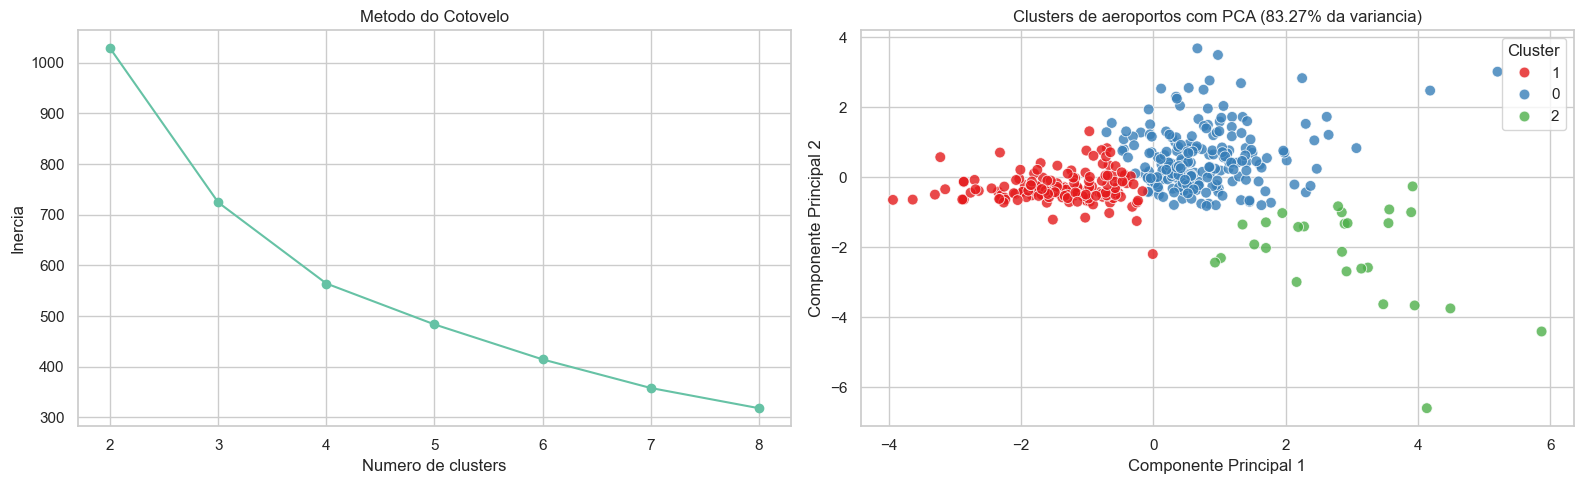

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(metricas_k['k'], metricas_k['inercia'], marker='o')
axes[0].set_title('Metodo do Cotovelo')
axes[0].set_xlabel('Numero de clusters')
axes[0].set_ylabel('Inercia')

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=airport_profiles['Cluster'],
    palette='Set1',
    s=60,
    alpha=0.8,
    ax=axes[1]
)
axes[1].set_title(f'Clusters de aeroportos com PCA ({variancia_total:.2f}% da variancia)')
axes[1].set_xlabel('Componente Principal 1')
axes[1].set_ylabel('Componente Principal 2')

plt.tight_layout()
plt.show()

### Leitura da Modelagem Não Supervisionada

A modelagem não supervisionada mostrou que os aeroportos podem ser segmentados em três grupos com características operacionais distintas.

A definição de k = 3 foi sustentada pelo Método do Cotovelo, porque é o primeiro ponto em que a redução da inércia perde intensidade de forma visível. Além disso, a visualização em PCA indicou separação visual razoável entre os grupos, com 83,27% da variância explicada nas duas primeiras componentes.

Esse resultado sugere a presença de padrões estruturais nos dados, indicando que parte dos aeroportos compartilha comportamentos semelhantes, enquanto outros apresentam perfis mais específicos. A caracterização final de cada cluster deve ser feita com base nas medianas das variáveis originais, permitindo descrever os grupos de forma objetiva, sem atribuir rótulos arbitrários.

## 8. Conclusões Finais e Apresentação Crítica

Neste estudo, desenvolvemos um pipeline de machine learning para explorar e entender padrões de atrasos de voos nos Estados Unidos. Após as etapas de exploração e modelagem, consolidamos os seguintes aprendizados:

- **O Limite das Variáveis de Agendamento:** Treinar um modelo com dados de planejamento pré-voo (horário previsto, aeroporto, companhia) demonstrou ter um teto de aprendizado. Apenas o volume de dados não substitui a necessidade de variáveis de contexto. É possível que fatores externos não capturados nesta base limitem a capacidade preditiva de qualquer algoritmo neste cenário específico.
  
- **Desempenho do XGBoost e Tolerância de Negócio:** Na avaliação dos algoritmos supervisionados, o **XGBoost apresentou os melhores resultados relativos**. Fica como um aprendizado a importância de formular bem o problema de negócio: ao criarmos também um modelo focado **em atrasos superiores a 15 minutos**, simulamos um cenário mais alinhado à percepção real de atraso, o que pode dar mais sentido prático ao modelo.

- **Perfis Operacionais com K-Means:** A aplicação de técnicas não supervisionadas nos ajudou a resumir a complexidade do problema. O modelo K-Means agrupou aeroportos com características aproximadas, separando de forma mais clara os grandes *hubs* (altíssimo movimento e atraso diluído) de perfis e volumes mais singulares.

**Proposta de Melhorias e Próximos Passos:**
- **Inclusão de Variáveis Externas:** Para desenvolvimentos futuros, talvez o cruzamento desta base estatística com dados de histórico de eventos climáticos traga novas perspectivas. A **hipótese** é de que informações metereológicas possam ajudar o modelo a capturar padrões de atraso mais complexos, porém isso ainda precisa ser testado com dados reais.
- **Engenharia de Variáveis (Features):** Testar os agrupamentos (clusters) criados na etapa não supervisionada como novas variáveis de entrada para os algoritmos de classificação.